## TallerNa

In [107]:

# 1) Exploración inicial de las variables


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset desde GitHub
url = "https://github.com/Kalbam/Datos/raw/main/base_imputacion_mixta_1000.csv"
df = pd.read_csv(url)

# Vista general de los primeros registros
print("=== Primeras filas ===")
display(df.head())

# Información de estructura
print("\n=== Información general ===")
print(df.info())

# Resumen estadístico de las variables numéricas
print("\n=== Descripción estadística (numéricas) ===")
display(df.describe())




=== Primeras filas ===


,fecha,sexo,ciudad,nivel_educativo,segmento,estado_civil,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
0,2024-01-01,F,Medellín,NaN,B,Unión libre,19.0,161.821754,3574.753806,1832.731832,640.465372,119.202995
1,2024-01-02,F,Barranquilla,NaN,B,NaN,52.0,167.819566,3163.626815,NaN,533.108430,124.457874
2,2024-01-03,M,Bogotá,Secundaria,B,Soltero/a,38.0,165.756219,2765.672259,1219.535074,491.016910,NaN
3,2024-01-04,F,Bogotá,NaN,B,Casado/a,57.0,160.642670,4320.397345,1908.324816,NaN,129.426792
4,2024-01-05,M,Cali,Técnico,B,Soltero/a,67.0,151.402909,NaN,1887.385697,610.213994,133.916319



=== Información general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               1000 non-null   object 
 1   sexo                980 non-null    object 
 2   ciudad              950 non-null    object 
 3   nivel_educativo     900 non-null    object 
 4   segmento            800 non-null    object 
 5   estado_civil        650 non-null    object 
 6   edad                970 non-null    float64
 7   altura_cm           920 non-null    float64
 8   ingresos            880 non-null    float64
 9   gasto_mensual       750 non-null    float64
 10  puntuacion_credito  500 non-null    float64
 11  demanda             850 non-null    float64
dtypes: float64(6), object(6)
memory usage: 93.9+ KB
None

=== Descripción estadística (numéricas) ===


,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
count,970.000000,920.000000,880.000000,750.000000,500.000000,850.000000
mean,42.861856,167.760096,3681.294745,1687.810749,599.077500,160.305759
std,14.621382,9.275530,1079.326096,582.070174,79.828186,25.357794
min,18.000000,140.000000,487.662547,100.000000,373.657944,99.875828
25%,30.000000,161.488768,2999.416229,1309.239768,544.467843,139.505538
50%,43.000000,167.714614,3669.620507,1676.193764,599.692595,160.721251
75%,55.000000,173.999069,4375.093656,2063.260990,653.345068,181.100754
max,69.000000,195.766921,7016.246936,3532.593603,823.539585,222.093047


In [108]:
from scipy.stats import kstest
import numpy as np

titulos = df.select_dtypes(include=[np.number]).columns.tolist() 


for col in titulos:
    datos = df[col].dropna()
    stat_col, p_col = kstest(datos, "norm", args=(datos.mean(), datos.std(ddof=1)))
    print(f"{col} -> KS = {stat_col:.4f}, p = {p_col:.4f}")



edad -> KS = 0.0728, p = 0.0001
altura_cm -> KS = 0.0225, p = 0.7320
ingresos -> KS = 0.0192, p = 0.8950
gasto_mensual -> KS = 0.0183, p = 0.9589
puntuacion_credito -> KS = 0.0175, p = 0.9974
demanda -> KS = 0.0503, p = 0.0260


##  Prueba de normalidad (Kolmogorov–Smirnov)

En este bloque se aplica la **prueba de Kolmogorov–Smirnov (KS test)** a todas las variables numéricas del dataset con el fin de evaluar si siguen una distribución normal:

- **Selección de variables**: Se extraen todas las columnas numéricas del DataFrame.  


- Si el valor-p < 0.05, se rechaza la hipótesis nula de normalidad, lo que indica que la variable no sigue una distribución normal.  
- Si el valor-p ≥ 0.05, no se rechaza la normalidad, por lo que la variable puede considerarse aproximadamente normal.

-Obtenemos que edad y demanda no son normales mientras que el resto de variables numericas lo son


In [109]:
pd.DataFrame(df.columns, columns=["Nombres de variables"])


,Nombres de variables
0,fecha
1,sexo
2,ciudad
3,nivel_educativo
4,segmento
5,estado_civil
6,edad
7,altura_cm
8,ingresos
9,gasto_mensual


=== Resumen de valores nulos ===
                    Nulos  Porcentaje (%)
puntuacion_credito    500            50.0
estado_civil          350            35.0
gasto_mensual         250            25.0
segmento              200            20.0
demanda               150            15.0
ingresos              120            12.0
nivel_educativo       100            10.0
altura_cm              80             8.0
ciudad                 50             5.0
edad                   30             3.0
sexo                   20             2.0
fecha                   0             0.0


C:\Users\migue\AppData\Local\Temp\ipykernel_37120\1428512382.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=missing_summary_sorted.index,


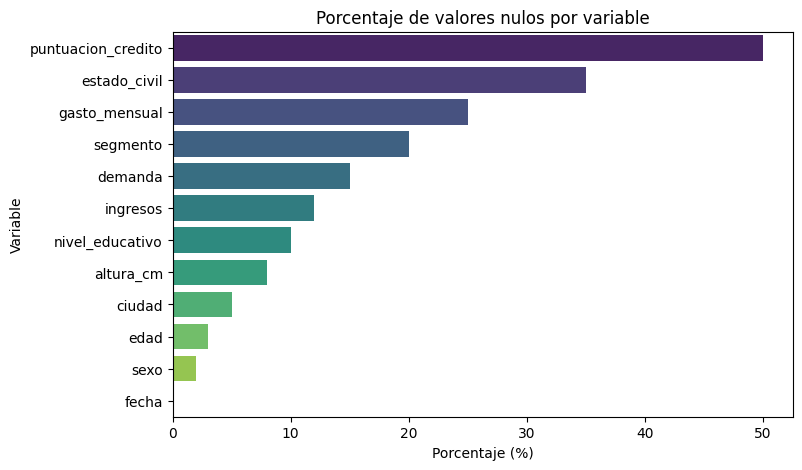

In [110]:
total = len(df)
null_counts = df.isna().sum()
null_percent = (null_counts / total) * 100


missing_summary = pd.DataFrame({
    "Nulos": null_counts,
    "Porcentaje (%)": null_percent.round(2)
})

missing_summary_sorted = missing_summary.sort_values("Porcentaje (%)", ascending=False)

print("=== Resumen de valores nulos ===")
print(missing_summary_sorted)


plt.figure(figsize=(8,5))
sns.barplot(y=missing_summary_sorted.index, 
            x=missing_summary_sorted["Porcentaje (%)"], 
            palette="viridis")
plt.title("Porcentaje de valores nulos por variable")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Variable")
plt.show()


## Análisis de valores faltantes

En este bloque se identifican y visualizan los valores nulos en el dataset:

- **Conteo y porcentaje de nulos**:  
  Se calcula para cada variable:
  - Número total de valores faltantes (`Nulos`).  
  - Porcentaje que representan respecto al total de registros (`Porcentaje (%)`).  

- **Resumen ordenado**:  
  Se construye un DataFrame con estos indicadores y se ordena de mayor a menor porcentaje de ausencia.  

- **Visualización**:  
  Se genera un gráfico de barras que muestra el porcentaje de datos faltantes por variable, facilitando la detección de aquellas con mayor nivel de ausencia.  



In [111]:
from sklearn.impute import SimpleImputer

# Copia del df original
df_imputado = df.copy()

# Imputacion numericas
# edad (no normal) -> mediana
imp_median = SimpleImputer(strategy="median")
df_imputado[["edad"]] = imp_median.fit_transform(df_imputado[["edad"]])

# altura_cm (normal) -> media
imp_mean = SimpleImputer(strategy="mean")
df_imputado[["altura_cm"]] = imp_mean.fit_transform(df_imputado[["altura_cm"]])

# Imputación categóricas
imp_moda = SimpleImputer(strategy="most_frequent")
df_imputado[["ciudad"]] = imp_moda.fit_transform(df_imputado[["ciudad"]])
df_imputado[["sexo"]]   = imp_moda.fit_transform(df_imputado[["sexo"]])

# Verificación
print("\nNulos originales:\n", df.isna().sum())
print("Valores nulos después de imputar:")
print(df_imputado[["edad","altura_cm","ciudad","sexo"]].isna().sum())





Nulos originales:
 fecha                   0
sexo                   20
ciudad                 50
nivel_educativo       100
segmento              200
estado_civil          350
edad                   30
altura_cm              80
ingresos              120
gasto_mensual         250
puntuacion_credito    500
demanda               150
dtype: int64
Valores nulos después de imputar:
edad         0
altura_cm    0
ciudad       0
sexo         0
dtype: int64


## Imputación de valores faltantes

En este bloque se aplican distintas estrategias de imputación, seleccionadas según la naturaleza y distribución de cada variable:

- **Variables numéricas**:  
  - `edad`: No sigue distribución normal, por lo que se imputan los valores faltantes con la **mediana** (más robusta frente a valores atípicos).  
  - `altura_cm`: Aproximadamente normal, se imputan con la **media**.  

- **Variables categóricas**:  
  - `ciudad` y `sexo`: Se imputan con la **moda** (categoría más frecuente).  
 



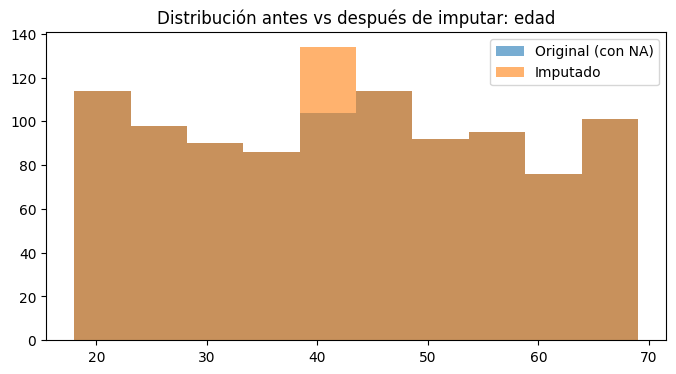

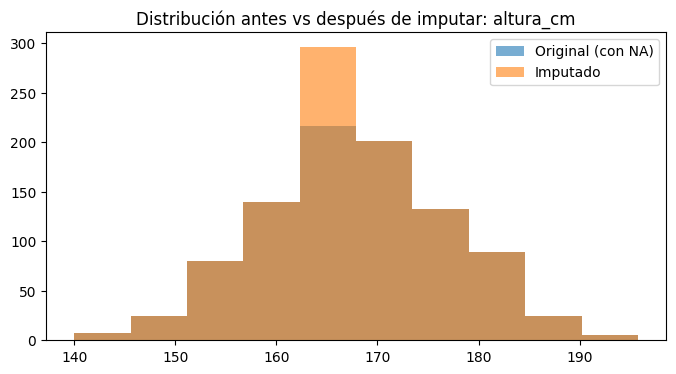

In [112]:
# --- Comparación visual entre original vs imputado ---
variables = ["edad", "altura_cm"]

for var in variables:
    plt.figure(figsize=(8,4))
    plt.hist(df[var].dropna(), bins=10, alpha=0.6, label="Original (con NA)")
    plt.hist(df_imputado[var], bins=10, alpha=0.6, label="Imputado")
    plt.title(f"Distribución antes vs después de imputar: {var}")
    plt.legend()
    plt.show()


In [113]:
# =========================================================
# PRUEBAS ESTADÍSTICAS: ¿cambió la distribución tras imputar?
# =========================================================
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind, chi2_contingency

alpha = 0.05


num_normal    = ["altura_cm"]
num_nonnormal = ["edad"]

print("=== NUMÉRICAS: Comparación antes (df) vs después (df_imputado) ===")
for var in num_normal + num_nonnormal:
    x0 = df[var].dropna()          
    x1 = df_imputado[var]          

    # KS de dos muestras (distribución completa)
    ks_stat, ks_p = ks_2samp(x0, x1)

    # Prueba de tendencia central
    if var in num_normal:
        
        t_stat, t_p = ttest_ind(x0, x1, equal_var=False, nan_policy="omit")
        trend_name, stat_fmt, p_trend = "t de Welch (medias)", f"t={t_stat:.3f}", t_p
    else:
        
        u_stat, u_p = mannwhitneyu(x0, x1, alternative="two-sided")
        trend_name, stat_fmt, p_trend = "Mann–Whitney U (medianas)", f"U={u_stat:.1f}", u_p

    print(f"\nVariable: {var}")
    print(f"  KS 2-samples: D={ks_stat:.3f}, p={ks_p:.4f}  -> "
          f"{'NO se detecta cambio (p≥0.05)' if ks_p>=alpha else 'SÍ cambia la distribución (p<0.05)'}")
    print(f"  {trend_name}: {stat_fmt}, p={p_trend:.4f} -> "
          f"{'Sin diferencia significativa' if p_trend>=alpha else 'Diferencia significativa'}")



=== NUMÉRICAS: Comparación antes (df) vs después (df_imputado) ===

Variable: altura_cm
  KS 2-samples: D=0.040, p=0.4079  -> NO se detecta cambio (p≥0.05)
  t de Welch (medias): t=0.000, p=1.0000 -> Sin diferencia significativa

Variable: edad
  KS 2-samples: D=0.015, p=0.9998  -> NO se detecta cambio (p≥0.05)
  Mann–Whitney U (medianas): U=485075.0, p=0.9953 -> Sin diferencia significativa


## Pruebas estadísticas: comparación antes vs. después de imputar

En este bloque se evalúa si la imputación alteró la distribución de las variables mediante pruebas de hipótesis:

- **Variables numéricas normales** (`altura_cm`):  
  - Se usa **Kolmogorov–Smirnov de dos muestras** (KS) para comparar la distribución completa.  
  - Se aplica la **prueba t de Welch**, que contrasta las medias entre los datos originales y los imputados, sin asumir igualdad de varianzas.  

- **Variables numéricas no normales** (`edad`):  
  - Se usa **KS de dos muestras** para comparar la forma de la distribución.  
  - Se aplica la **prueba de Mann–Whitney U**, no paramétrica, para contrastar medianas.  

- **Interpretación de resultados**:  
  - Si el valor-p ≥ 0.05 → No hay evidencia estadística de cambio en la distribución tras imputar.  
  - Si el valor-p < 0.05 → Sí se detecta un cambio significativo en la distribución.  



C:\Users\migue\AppData\Local\Temp\ipykernel_37120\817926408.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_37120\817926408.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")


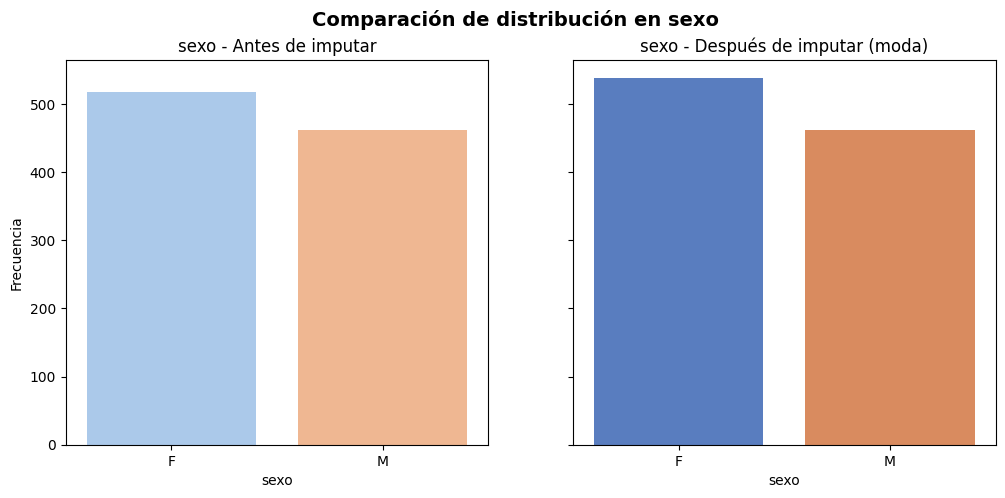

C:\Users\migue\AppData\Local\Temp\ipykernel_37120\817926408.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_37120\817926408.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")


=== sexo ===
Proporciones antes:
 sexo
F    0.529
M    0.471
Name: count, dtype: float64
Proporciones después:
 sexo
F    0.538
M    0.462
Name: count, dtype: float64
Chi2 = 0.141, gl = 1, p = 0.7074 → No se rechaza H0 (distribuciones iguales)
------------------------------------------------------------


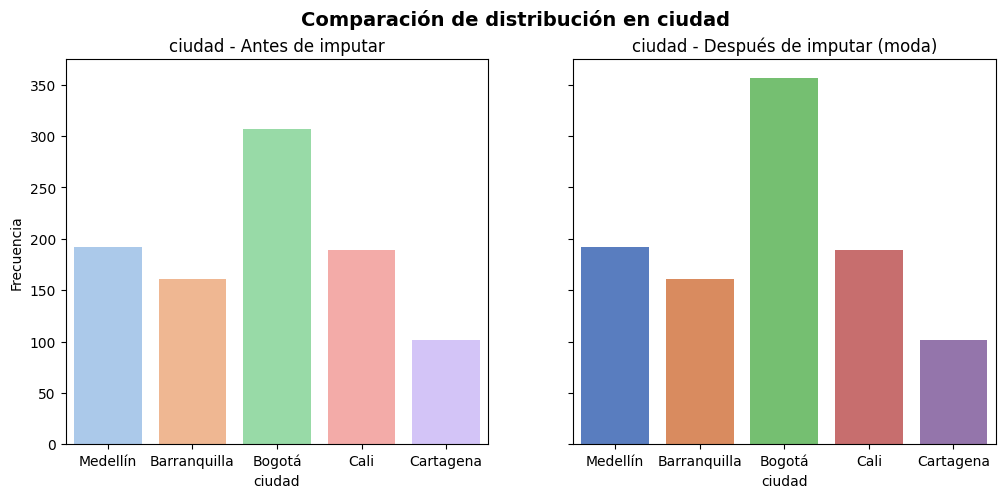

=== ciudad ===
Proporciones antes:
 ciudad
Barranquilla    0.169
Bogotá          0.323
Cali            0.199
Cartagena       0.106
Medellín        0.202
Name: count, dtype: float64
Proporciones después:
 ciudad
Barranquilla    0.161
Bogotá          0.357
Cali            0.189
Cartagena       0.101
Medellín        0.192
Name: count, dtype: float64
Chi2 = 2.485, gl = 4, p = 0.6474 → No se rechaza H0 (distribuciones iguales)
------------------------------------------------------------


In [114]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

variables = ["sexo", "ciudad"]

for var in variables:
    # Gráficos comparativos
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    sns.countplot(x=df[var], ax=axes[0], palette="pastel")
    axes[0].set_title(f"{var} - Antes de imputar")
    axes[0].set_ylabel("Frecuencia")

    sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")
    axes[1].set_title(f"{var} - Después de imputar (moda)")
    axes[1].set_ylabel("Frecuencia")

    plt.suptitle(f"Comparación de distribución en {var}", fontsize=14, weight="bold")
    plt.show()

    #  Chi-cuadrado 
    orig_counts = df[var].value_counts().sort_index()
    imp_counts  = df_imputado[var].value_counts().sort_index()

   
    orig_counts, imp_counts = orig_counts.align(imp_counts, fill_value=0)

    tabla = pd.DataFrame({"original": orig_counts, "imputada": imp_counts}).T

    chi2, p, dof, expected = chi2_contingency(tabla)

    print(f"=== {var} ===")
    print("Proporciones antes:\n", (orig_counts / orig_counts.sum()).round(3))
    print("Proporciones después:\n", (imp_counts / imp_counts.sum()).round(3))
    print(f"Chi2 = {chi2:.3f}, gl = {dof}, p = {p:.4f} → "
          f"{'No se rechaza H0 (distribuciones iguales)' if p > 0.05 else 'Se rechaza H0 (distribuciones diferentes)'}")
    print("-"*60)


## Variables categóricas: comparación antes vs. después de imputar

En este bloque se evalúa si la imputación con la **moda** alteró la distribución de las variables categóricas (`sexo`, `ciudad`):

- **Visualización**:  
  - Se generan gráficos de barras (antes y después de imputar) para comparar la frecuencia de cada categoría.  
  - Esto permite observar de manera intuitiva si la imputación modificó la distribución de las categorías.  

- **Prueba estadística (Chi-cuadrado de homogeneidad)**:  
  - Se construyen tablas de frecuencias relativas antes y después de la imputación.  
  - Se aplica la prueba chi-cuadrado para contrastar si ambas distribuciones son estadísticamente iguales.  
  - **Interpretación**:  
    - Si el valor-p > 0.05 → No hay diferencias significativas; la imputación no cambió la distribución.  
    - Si el valor-p < 0.05 → Sí hay diferencias significativas; la imputación modificó la distribución.  




In [115]:
# Conteo de NA en el df imputado
faltantes_df = df_imputado.isna().sum().sort_values(ascending=False)
faltantes_pct = (df_imputado.isna().mean() * 100).sort_values(ascending=False)

faltantes_resumen = pd.DataFrame({
    "Nulos": faltantes_df,
    "Porcentaje (%)": faltantes_pct.round(2)
})

print("=== Resumen de valores nulos después de imputar ===")
print(faltantes_resumen)


=== Resumen de valores nulos después de imputar ===
                    Nulos  Porcentaje (%)
puntuacion_credito    500            50.0
estado_civil          350            35.0
gasto_mensual         250            25.0
segmento              200            20.0
demanda               150            15.0
ingresos              120            12.0
nivel_educativo       100            10.0
fecha                   0             0.0
ciudad                  0             0.0
sexo                    0             0.0
altura_cm               0             0.0
edad                    0             0.0


=== Pruebas de normalidad ===

Variable: ingresos
  KS: D=0.019, p=0.8950 → Normal


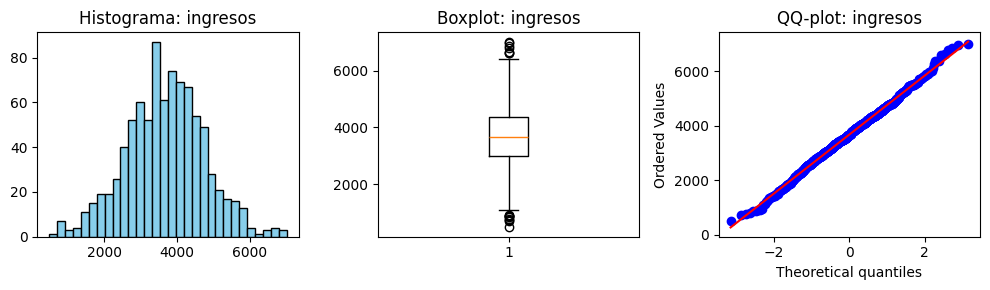


Variable: demanda
  KS: D=0.050, p=0.0260 → No normal


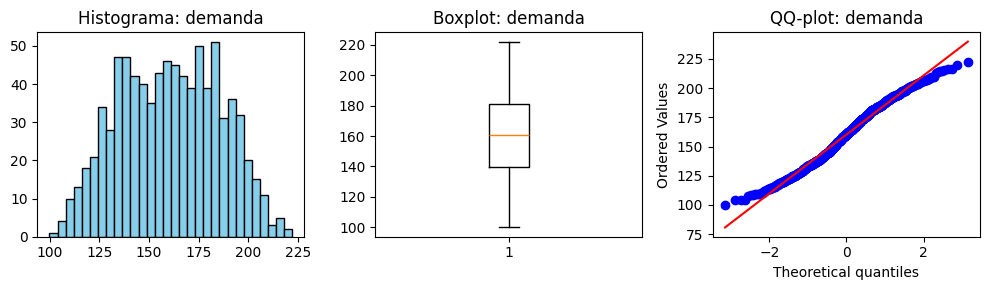

In [116]:
from scipy.stats import kstest, normaltest, probplot
import matplotlib.pyplot as plt

variables = ["ingresos", "demanda"]

print("=== Pruebas de normalidad ===")
for var in variables:
    datos = df[var].dropna()  

    # Kolmogorov-Smirnov contra N(media, sd)
    ks_stat, ks_p = kstest(datos, "norm", args=(datos.mean(), datos.std(ddof=1)))

    # D’Agostino-Pearson (n>20)
    dag_stat, dag_p = normaltest(datos)

    print(f"\nVariable: {var}")
    print(f"  KS: D={ks_stat:.3f}, p={ks_p:.4f} → {'Normal' if ks_p>0.05 else 'No normal'}")
    

    # --- Gráficos ---
    plt.figure(figsize=(10,3))
    
    plt.subplot(1,3,1)
    plt.hist(datos, bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Histograma: {var}")

    plt.subplot(1,3,2)
    plt.boxplot(datos, vert=True)
    plt.title(f"Boxplot: {var}")

    plt.subplot(1,3,3)
    probplot(datos, dist="norm", plot=plt)
    plt.title(f"QQ-plot: {var}")

    plt.tight_layout()
    plt.show()


## Pruebas de normalidad y análisis gráfico

En este bloque se evalúa la normalidad de las variables **`ingresos`** y **`demanda`** usando pruebas estadísticas y representaciones gráficas:

- **Pruebas de normalidad**:  
  - **Kolmogorov–Smirnov (KS)**: compara la distribución de los datos con una normal teórica (ajustada con media y desviación estándar muestral).  
 

- **Interpretación**:  
  - Si el valor-p > 0.05 → No se rechaza la hipótesis nula de normalidad.  
  - Si el valor-p ≤ 0.05 → Se rechaza la normalidad (los datos no siguen distribución normal).  



In [117]:
from sklearn.impute import SimpleImputer


df_imp3 = df_imputado.copy()

# Categóricas 
imp_moda = SimpleImputer(strategy="most_frequent")
df_imp3[["segmento"]] = imp_moda.fit_transform(df_imp3[["segmento"]])
df_imp3[["nivel_educativo"]] = imp_moda.fit_transform(df_imp3[["nivel_educativo"]])

# Numéricas
# ingresos (normal) -> media
imp_media = SimpleImputer(strategy="mean")
df_imp3[["ingresos"]] = imp_media.fit_transform(df_imp3[["ingresos"]])

# demanda (no normal) -> mediana
imp_mediana = SimpleImputer(strategy="median")
df_imp3[["demanda"]] = imp_mediana.fit_transform(df_imp3[["demanda"]])

# --- Verificación ---
print("Valores nulos después de imputar estas 4 variables:")
print(df_imp3[["segmento", "nivel_educativo", "ingresos", "demanda"]].isna().sum())


Valores nulos después de imputar estas 4 variables:
segmento           0
nivel_educativo    0
ingresos           0
demanda            0
dtype: int64


In [118]:
# =========================================================
# PRUEBAS ESTADÍSTICAS: ¿cambió la distribución tras imputar?
# =========================================================
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind

alpha = 0.05

num_normal    = ["ingresos"]
num_nonnormal = ["demanda"]

print("=== NUMÉRICAS: Comparación antes (df) vs después (df_imp3) ===")
for var in num_normal + num_nonnormal:
    x0 = df[var].dropna()          
    x1 = df_imp3[var]            

    
    ks_stat, ks_p = ks_2samp(x0, x1)

    # Prueba de tendencia central
    if var in num_normal:
       
        t_stat, t_p = ttest_ind(x0, x1, equal_var=False, nan_policy="omit")
        trend_name, stat_fmt, p_trend = "t de Welch (medias)", f"t={t_stat:.3f}", t_p
    else:
        
        u_stat, u_p = mannwhitneyu(x0, x1, alternative="two-sided")
        trend_name, stat_fmt, p_trend = "Mann–Whitney U (medianas)", f"U={u_stat:.1f}", u_p

    print(f"\nVariable: {var}")
    print(f"  KS 2-samples: D={ks_stat:.3f}, p={ks_p:.4f}  -> "
          f"{'NO se detecta cambio (p≥0.05)' if ks_p>=alpha else 'SÍ cambia la distribución (p<0.05)'}")
    print(f"  {trend_name}: {stat_fmt}, p={p_trend:.4f} -> "
          f"{'Sin diferencia significativa' if p_trend>=alpha else 'Diferencia significativa'}")

=== NUMÉRICAS: Comparación antes (df) vs después (df_imp3) ===

Variable: ingresos
  KS 2-samples: D=0.060, p=0.0633  -> NO se detecta cambio (p≥0.05)
  t de Welch (medias): t=0.000, p=1.0000 -> Sin diferencia significativa

Variable: demanda
  KS 2-samples: D=0.075, p=0.0107  -> SÍ cambia la distribución (p<0.05)
  Mann–Whitney U (medianas): U=425000.0, p=1.0000 -> Sin diferencia significativa


## Se detecta cambio en la distribucion

- La variable segmento presenta un cambio en su distribusion luego de imputar por la mediana

In [119]:
# ============================================
# Imputación de 'demanda' con DONANTES KNN
# (hot-deck numérico basado en vecinos, SIN gasto_mensual)
# ============================================
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp, mannwhitneyu

rng = np.random.default_rng(42)

# --- 1) Base de trabajo ---
df_imp3 = df_imputado.copy()  # parte de tu dataset ya imputado previamente

# --- 2) Reimputaciones básicas para asegurar predictores ---
imp_moda = SimpleImputer(strategy="most_frequent")
df_imp3[["segmento"]] = imp_moda.fit_transform(df_imp3[["segmento"]])
df_imp3[["nivel_educativo"]] = imp_moda.fit_transform(df_imp3[["nivel_educativo"]])

imp_media = SimpleImputer(strategy="mean")
df_imp3[["ingresos"]] = imp_media.fit_transform(df_imp3[["ingresos"]])

# --- 3) Configuración KNN-donor para 'demanda' ---
target = "demanda"

# Predictores seleccionados (sin gasto_mensual)
predictors = [c for c in ["ingresos", "edad", "altura_cm"] if c in df_imp3.columns]

mask_na = df_imp3[target].isna()
donors = df_imp3.loc[~mask_na, predictors + [target]].dropna(subset=predictors)
receivers = df_imp3.loc[mask_na, predictors]

receivers_ok = receivers.dropna()
idx_receivers_ok = receivers_ok.index

if donors.empty or receivers_ok.empty:
    print("No hay suficientes donantes o receptores completos. Fallback global (muestreo de observados).")
    obs_vals = df_imp3[target].dropna().values
    if len(obs_vals) > 0:
        df_imp3.loc[mask_na, target] = rng.choice(obs_vals, size=mask_na.sum(), replace=True)
    else:
        raise ValueError("No hay valores observados de 'demanda' para muestrear.")
else:
    # --- 3.1) Escalar predictores ---
    scaler = StandardScaler()
    X_don = scaler.fit_transform(donors[predictors].values)
    X_rec = scaler.transform(receivers_ok.values)

    # --- 3.2) KNN sobre donantes ---
    k = min(7, len(donors))  # no exceder número de donantes
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    knn.fit(X_don)

    distances, indices = knn.kneighbors(X_rec, return_distance=True)

    donor_vals = donors[target].values
    imputados = []
    for row_ix in range(indices.shape[0]):
        neigh_ixs = indices[row_ix, :]
        # Elegimos UN vecino al azar entre los k
        pick = rng.integers(0, len(neigh_ixs))
        imputados.append(donor_vals[neigh_ixs[pick]])

    df_imp3.loc[idx_receivers_ok, target] = imputados

    # Fallback global si aún quedan NA
    still_na = df_imp3[target].isna()
    if still_na.any():
        obs_vals = df_imp3[target].dropna().values
        df_imp3.loc[still_na, target] = rng.choice(obs_vals, size=still_na.sum(), replace=True)


x0 = df[target].dropna()   # original observado
x1 = df_imp3[target]       # nueva imputada

ks_stat, ks_p = ks_2samp(x0, x1)
mw_p = mannwhitneyu(x0, x1, alternative="two-sided").pvalue

print("=== Validación demanda (KNN-donor hot-deck, sin gasto_mensual) ===")
print(f"KS 2-muestras: p = {ks_p:.4f}  -> {'NO cambia' if ks_p>=0.05 else 'Cambia'} la forma")
print(f"Mann–Whitney:  p = {mw_p:.4f}  -> {'Sin diferencia de mediana' if mw_p>=0.05 else 'Diferencia de mediana'}")




# --- Verificación ---
print("Valores nulos después de imputar estas 4 variables:")
print(df_imp3[["segmento", "nivel_educativo", "ingresos", "demanda"]].isna().sum())




=== Validación demanda (KNN-donor hot-deck, sin gasto_mensual) ===
KS 2-muestras: p = 1.0000  -> NO cambia la forma
Mann–Whitney:  p = 0.8246  -> Sin diferencia de mediana
Valores nulos después de imputar estas 4 variables:
segmento           0
nivel_educativo    0
ingresos           0
demanda            0
dtype: int64


## Cambio de metodo

- Al utilizar knn para imputar la variable demanda se preserva la distribucion de la variable original

## Imputación adicional de variables faltantes

En este bloque se imputan otras variables del dataset, siguiendo el criterio de normalidad/no normalidad y la naturaleza de las variables:

- **Categóricas**:  
  - `segmento` y `nivel_educativo`: imputadas con la **moda** (categoría más frecuente).  

- **Numéricas**:  
  - `ingresos`: presenta distribución aproximadamente normal, se imputan valores faltantes con la **media**.  
  - `demanda`: no sigue una distribución normal, se imputan valores faltantes con la **mediana**.  




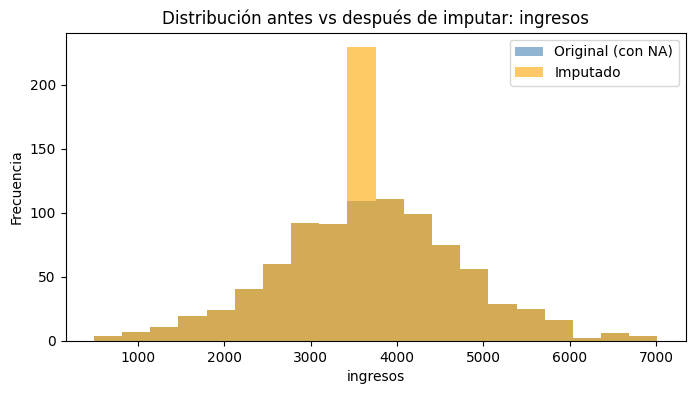

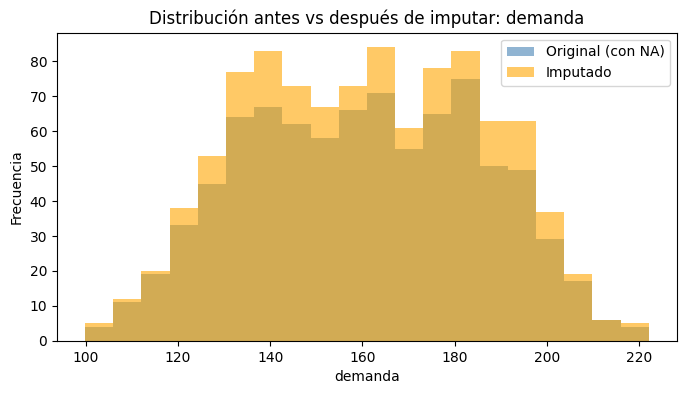

In [120]:
import matplotlib.pyplot as plt

# Variables numéricas recién imputadas
variables_num = ["ingresos", "demanda"]

for var in variables_num:
    plt.figure(figsize=(8,4))
    plt.hist(df[var].dropna(), bins=20, alpha=0.6, label="Original (con NA)", color="steelblue")
    plt.hist(df_imp3[var], bins=20, alpha=0.6, label="Imputado", color="orange")
    plt.title(f"Distribución antes vs después de imputar: {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()



In [121]:
# =========================================================
# PRUEBAS ESTADÍSTICAS: ¿cambió la distribución tras imputar?
# =========================================================
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind

alpha = 0.05

num_normal    = ["ingresos"]
num_nonnormal = ["demanda"]

print("=== NUMÉRICAS: Comparación antes (df) vs después (df_imp3) ===")
for var in num_normal + num_nonnormal:
    x0 = df[var].dropna()          
    x1 = df_imp3[var]            

    
    ks_stat, ks_p = ks_2samp(x0, x1)

    # Prueba de tendencia central
    if var in num_normal:
       
        t_stat, t_p = ttest_ind(x0, x1, equal_var=False, nan_policy="omit")
        trend_name, stat_fmt, p_trend = "t de Welch (medias)", f"t={t_stat:.3f}", t_p
    else:
        
        u_stat, u_p = mannwhitneyu(x0, x1, alternative="two-sided")
        trend_name, stat_fmt, p_trend = "Mann–Whitney U (medianas)", f"U={u_stat:.1f}", u_p

    print(f"\nVariable: {var}")
    print(f"  KS 2-samples: D={ks_stat:.3f}, p={ks_p:.4f}  -> "
          f"{'NO se detecta cambio (p≥0.05)' if ks_p>=alpha else 'SÍ cambia la distribución (p<0.05)'}")
    print(f"  {trend_name}: {stat_fmt}, p={p_trend:.4f} -> "
          f"{'Sin diferencia significativa' if p_trend>=alpha else 'Diferencia significativa'}")


=== NUMÉRICAS: Comparación antes (df) vs después (df_imp3) ===

Variable: ingresos
  KS 2-samples: D=0.060, p=0.0633  -> NO se detecta cambio (p≥0.05)
  t de Welch (medias): t=0.000, p=1.0000 -> Sin diferencia significativa

Variable: demanda
  KS 2-samples: D=0.012, p=1.0000  -> NO se detecta cambio (p≥0.05)
  Mann–Whitney U (medianas): U=422461.0, p=0.8246 -> Sin diferencia significativa


## Pruebas estadísticas para nuevas imputaciones

En este bloque se evalúa si la imputación de las variables **`ingresos`** y **`demanda`** modificó significativamente su distribución respecto a los datos originales:

- **Kolmogorov–Smirnov (KS de dos muestras)**:  
  - Contrasta la distribución completa antes vs. después de imputar.  

- **Prueba de tendencia central**:  
  - `ingresos` (numérica normal): se aplica la **t de Welch**, adecuada cuando no se asume igualdad de varianzas.  
  - `demanda` (numérica no normal): se utiliza la prueba **Mann–Whitney U**, no paramétrica y robusta frente a distribuciones no normales.  

- **Interpretación**:  
  - Si el valor-p ≥ 0.05 → No hay evidencia estadística de que la imputación haya cambiado la distribución.  
  - Si el valor-p < 0.05 → Se detecta diferencia significativa tras la imputación.  



C:\Users\migue\AppData\Local\Temp\ipykernel_37120\1820473811.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_37120\1820473811.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imp3[var], ax=axes[1], palette="muted")


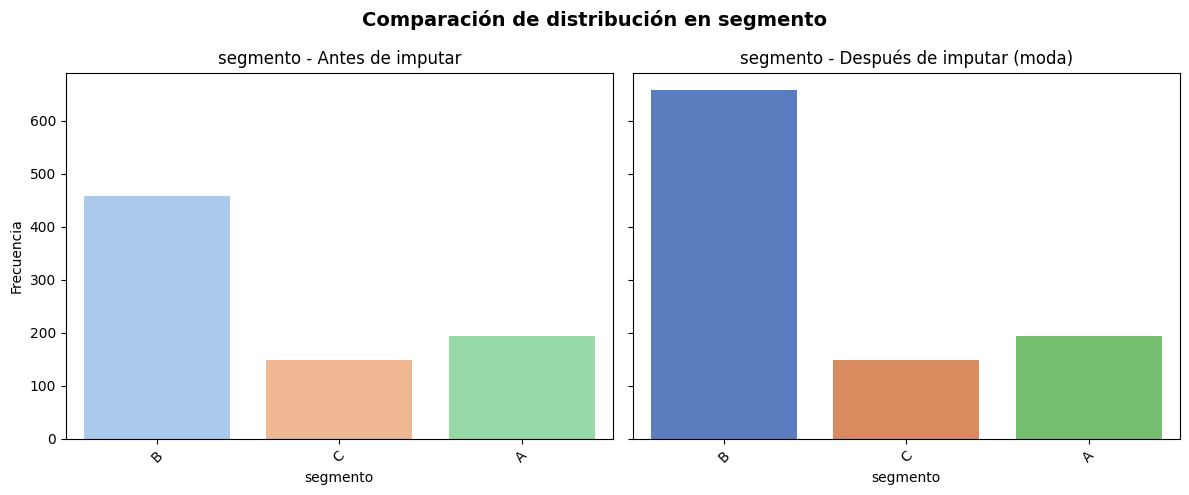

=== segmento ===
Proporciones antes:
 segmento
A    0.242
B    0.571
C    0.186
Name: count, dtype: float64
Proporciones después:
 segmento
A    0.194
B    0.657
C    0.149
Name: count, dtype: float64
Chi2 = 13.855, gl = 2, p = 0.0010 → Se rechaza H0 (distribuciones diferentes)
------------------------------------------------------------


C:\Users\migue\AppData\Local\Temp\ipykernel_37120\1820473811.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_37120\1820473811.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imp3[var], ax=axes[1], palette="muted")


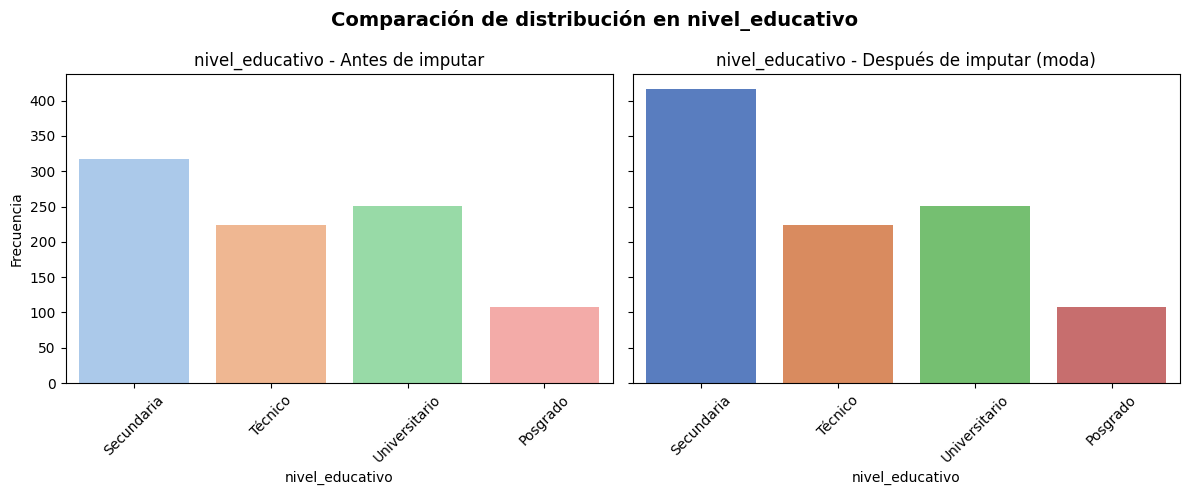

=== nivel_educativo ===
Proporciones antes:
 nivel_educativo
Posgrado         0.120
Secundaria       0.352
Técnico          0.249
Universitario    0.279
Name: count, dtype: float64
Proporciones después:
 nivel_educativo
Posgrado         0.108
Secundaria       0.417
Técnico          0.224
Universitario    0.251
Name: count, dtype: float64
Chi2 = 8.384, gl = 3, p = 0.0387 → Se rechaza H0 (distribuciones diferentes)
------------------------------------------------------------


In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

# Categóricas recién imputadas
variables = ["segmento", "nivel_educativo"]

for var in variables:
    #Gráficos comparativos 
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    sns.countplot(x=df[var], ax=axes[0], palette="pastel")
    axes[0].set_title(f"{var} - Antes de imputar")
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    sns.countplot(x=df_imp3[var], ax=axes[1], palette="muted")
    axes[1].set_title(f"{var} - Después de imputar (moda)")
    axes[1].set_ylabel("Frecuencia")
    axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle(f"Comparación de distribución en {var}", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

    # Chi-cuadrado
    orig_counts = df[var].value_counts().sort_index()
    imp_counts  = df_imp3[var].value_counts().sort_index()

    
    orig_counts, imp_counts = orig_counts.align(imp_counts, fill_value=0)

    
    tabla = pd.DataFrame({"original": orig_counts, "imputada": imp_counts}).T

    chi2, p, dof, expected = chi2_contingency(tabla)

    print(f"=== {var} ===")
    print("Proporciones antes:\n", (orig_counts / orig_counts.sum()).round(3))
    print("Proporciones después:\n", (imp_counts / imp_counts.sum()).round(3))
    print(f"Chi2 = {chi2:.3f}, gl = {dof}, p = {p:.4f} → "
          f"{'No se rechaza H0 (distribuciones iguales)' if p > 0.05 else 'Se rechaza H0 (distribuciones diferentes)'}")
    print("-"*60)


## Variables categóricas recién imputadas: validación

En este bloque se analizan las variables categóricas **`segmento`** y **`nivel_educativo`**, que fueron imputadas con la **moda**, para verificar si la imputación modificó su distribución original:

- **Visualización comparativa**:  
  - Se construyen gráficos de barras **antes vs. después de imputar** para observar cambios en las frecuencias de cada categoría.  
  - Se ajusta la visualización para rotar etiquetas y mejorar la legibilidad.  

- **Prueba estadística (Chi-cuadrado de homogeneidad)**:  
  - Se crean tablas de contingencia con proporciones de categorías en datos originales vs. imputados.  
  - Se aplica la prueba **Chi-cuadrado** para verificar si ambas distribuciones son estadísticamente iguales.  

- **Interpretación**:  
  - Si el valor-p ≥ 0.05 → No hay diferencias significativas, la imputación conserva la distribución.  
  - Si el valor-p < 0.05 → La imputación alteró la distribución de categorías.  

- En este caso obtenemos p valores menores al nivel de significancia por lo que el metodo que utilizamos para imputar cambio las distribuciones en ambas variables, por est0
- en otro bloque vamos a imputar por otro metodo estas mismas variables **`segmento`** y **`nivel_educativo`*


In [123]:
# =========================================================
# IMPUTACIÓN FINAL EN UN SOLO BLOQUE — TRABAJA SOBRE df_imp3
# =========================================================
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from scipy.stats import ks_2samp, mannwhitneyu

# -----------------------------
# 0) Punto de partida
# -----------------------------
rng = np.random.default_rng(42)

# df: DataFrame original (observado)
# df_imputado: tu DF base tras imputaciones previas generales
df_imp3 = df_imputado.copy()  # <- TODO sucede aquí

# -----------------------------
# 1) ingresos -> MEDIA
# -----------------------------
if "ingresos" in df_imp3.columns and df_imp3["ingresos"].isna().any():
    imp_media = SimpleImputer(strategy="mean")
    df_imp3[["ingresos"]] = imp_media.fit_transform(df_imp3[["ingresos"]])

# -----------------------------
# 2) demanda -> KNN-DONOR (hot-deck)
#    Predictores: ingresos, edad, altura_cm (sin gasto_mensual)
# -----------------------------
target = "demanda"
preds = [c for c in ["ingresos", "edad", "altura_cm"] if c in df_imp3.columns]

mask_na = df_imp3[target].isna()
donors = df_imp3.loc[~mask_na, preds + [target]].dropna(subset=preds)
receivers = df_imp3.loc[mask_na, preds]

if (len(preds) > 0) and (not donors.empty) and (receivers.shape[0] > 0):
    receivers_ok = receivers.dropna()
    idx_receivers_ok = receivers_ok.index

    if len(idx_receivers_ok) > 0:
        # Escalar predictores
        scaler = StandardScaler()
        X_don = scaler.fit_transform(donors[preds].values)
        X_rec = scaler.transform(receivers_ok.values)

        # KNN sobre donantes
        k = min(7, len(donors))
        knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
        knn.fit(X_don)

        _, indices = knn.kneighbors(X_rec, return_distance=True)
        donor_vals = donors[target].values

        imputados = []
        for row_ix in range(indices.shape[0]):
            neigh_ixs = indices[row_ix, :]
            pick = rng.integers(0, len(neigh_ixs))  # vecino aleatorio entre los k
            imputados.append(donor_vals[neigh_ixs[pick]])

        df_imp3.loc[idx_receivers_ok, target] = imputados

# Fallback global si aún quedan NA en demanda
still_na = df_imp3[target].isna()
if still_na.any():
    obs_vals = df_imp3[target].dropna().values
    if obs_vals.size > 0:
        df_imp3.loc[still_na, target] = rng.choice(obs_vals, size=still_na.sum(), replace=True)

# Validación distribución de demanda (opcional, solo imprime)
x0 = df[target].dropna()           # observado original
x1 = df_imp3[target].dropna()      # con imputación KNN-donor
if (len(x0) >= 3) and (len(x1) >= 3):
    ks_p = ks_2samp(x0, x1).pvalue
    mw_p = mannwhitneyu(x0, x1, alternative="two-sided").pvalue
    print("=== Validación DEMANDA (KNN-donor, sin gasto_mensual) ===")
    print(f"KS 2-muestras: p = {ks_p:.4f}  -> {'NO cambia' if ks_p>=0.05 else 'Cambia'} la forma")
    print(f"Mann–Whitney:  p = {mw_p:.4f}  -> {'Sin dif. mediana' if mw_p>=0.05 else 'Dif. mediana'}")

# -----------------------------
# 3) segmento -> HOT-DECK (por grupos de nivel_educativo)
# -----------------------------
def hot_deck_random(df, target, group_vars=None, seed=42):
    rng_local = np.random.default_rng(seed)
    out = df.copy()

    if group_vars is None:
        na_idx = out[out[target].isna()].index
        donors = out[target].dropna().values
        if len(na_idx) and len(donors):
            out.loc[na_idx, target] = rng_local.choice(donors, size=len(na_idx), replace=True)
    else:
        for _, group in out.groupby(group_vars):
            na_idx = group[group[target].isna()].index
            donors = group[target].dropna().values
            if len(na_idx) > 0:
                if len(donors) == 0:
                    donors = out[target].dropna().values  # fallback global
                if len(donors) > 0:
                    out.loc[na_idx, target] = rng_local.choice(donors, size=len(na_idx), replace=True)

        # Fallback si aún quedan NA
        rest_na = out[target].isna()
        if rest_na.any():
            donors = out[target].dropna().values
            if len(donors) > 0:
                out.loc[rest_na, target] = rng_local.choice(donors, size=rest_na.sum(), replace=True)

    return out

if "segmento" in df_imp3.columns:
    group_cols = ["nivel_educativo"] if "nivel_educativo" in df_imp3.columns else None
    df_imp3 = hot_deck_random(df_imp3, target="segmento", group_vars=group_cols, seed=42)

# -----------------------------
# 4) nivel_educativo -> KNN (clasificación)
#    Predictores numéricos: altura_cm, demanda, ingresos, edad
# -----------------------------
if "nivel_educativo" in df_imp3.columns:
    num_preds = [c for c in ["altura_cm", "demanda", "ingresos", "edad"] if c in df_imp3.columns]
    if len(num_preds) > 0:
        X_all = df_imp3[num_preds]
        y_all = df_imp3["nivel_educativo"]

        mask_y_obs = y_all.notna()
        X_train, y_train = X_all[mask_y_obs].dropna(), y_all[mask_y_obs].loc[X_all[mask_y_obs].dropna().index]
        X_miss_idx = y_all.isna() & X_all.notna().all(axis=1)

        if (len(X_train) > 0) and (X_miss_idx.any()):
            knn_clf = KNeighborsClassifier(n_neighbors=5, weights="distance")
            knn_clf.fit(X_train, y_train)
            y_pred = knn_clf.predict(X_all.loc[X_miss_idx])
            df_imp3.loc[X_miss_idx, "nivel_educativo"] = y_pred

# -----------------------------
# 5) Resumen rápido
# -----------------------------
print("\nNulos tras imputar (solo 4 vars):")
cols_check = [c for c in ["segmento", "nivel_educativo", "ingresos", "demanda"] if c in df_imp3.columns]
print(df_imp3[cols_check].isna().sum().sort_values(ascending=False))

# (Opcional) distribuciones para inspección:
if "segmento" in df.columns and "segmento" in df_imp3.columns:
    print("\nDistribución 'segmento' original vs imputado:")
    print(df["segmento"].value_counts(normalize=True).round(3))
    print(df_imp3["segmento"].value_counts(normalize=True).round(3))

if "nivel_educativo" in df.columns and "nivel_educativo" in df_imp3.columns:
    print("\nDistribución 'nivel_educativo' original vs imputado:")
    print(df["nivel_educativo"].value_counts(normalize=True).round(3))
    print(df_imp3["nivel_educativo"].value_counts(normalize=True).round(3))






=== Validación DEMANDA (KNN-donor, sin gasto_mensual) ===
KS 2-muestras: p = 1.0000  -> NO cambia la forma
Mann–Whitney:  p = 0.8246  -> Sin dif. mediana

Nulos tras imputar (solo 4 vars):
segmento           0
nivel_educativo    0
ingresos           0
demanda            0
dtype: int64

Distribución 'segmento' original vs imputado:
segmento
B    0.571
A    0.242
C    0.186
Name: proportion, dtype: float64
segmento
B    0.580
A    0.232
C    0.188
Name: proportion, dtype: float64

Distribución 'nivel_educativo' original vs imputado:
nivel_educativo
Secundaria       0.352
Universitario    0.279
Técnico          0.249
Posgrado         0.120
Name: proportion, dtype: float64
nivel_educativo
Secundaria       0.358
Universitario    0.277
Técnico          0.247
Posgrado         0.118
Name: proportion, dtype: float64


## Imputación con Hot-Deck aleatorio por grupos

En este bloque se implementa y aplica un método de **imputación Hot-Deck aleatorio**, que consiste en reemplazar los valores faltantes de una variable con valores observados de otros registros (donantes), seleccionados de manera aleatoria:


- **Aplicación**:  
  - Se imputó la variable **`segmento`**, tomando como referencia de agrupación la variable **`nivel_educativo`**, lo que permite mantener coherencia entre ambas.  

- **Verificación**:  
  - Se revisa que no queden valores faltantes en las variables imputadas.  
  - Se muestra la distribución relativa de `segmento` tras la imputación para confirmar que la técnica no genera sesgos extremos.  




## Imputación de `nivel_educativo` con KNN

En este bloque se aplica un enfoque supervisado para imputar valores faltantes en la variable **`nivel_educativo`** utilizando un **clasificador K-Nearest Neighbors (KNN)**:

- **Preparación de los datos**:  
  - Se definen como predictores numéricos las variables `altura_cm` y `demanda`, por su posible relación con el nivel educativo.  
  - Se separan los registros completos (sin NA en `nivel_educativo`) para entrenar el modelo y los registros con NA para imputar.  

- **Entrenamiento del modelo KNN**:  
  - Se utiliza un clasificador **KNN con k=5 vecinos**




C:\Users\migue\AppData\Local\Temp\ipykernel_37120\3189878945.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_37120\3189878945.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")


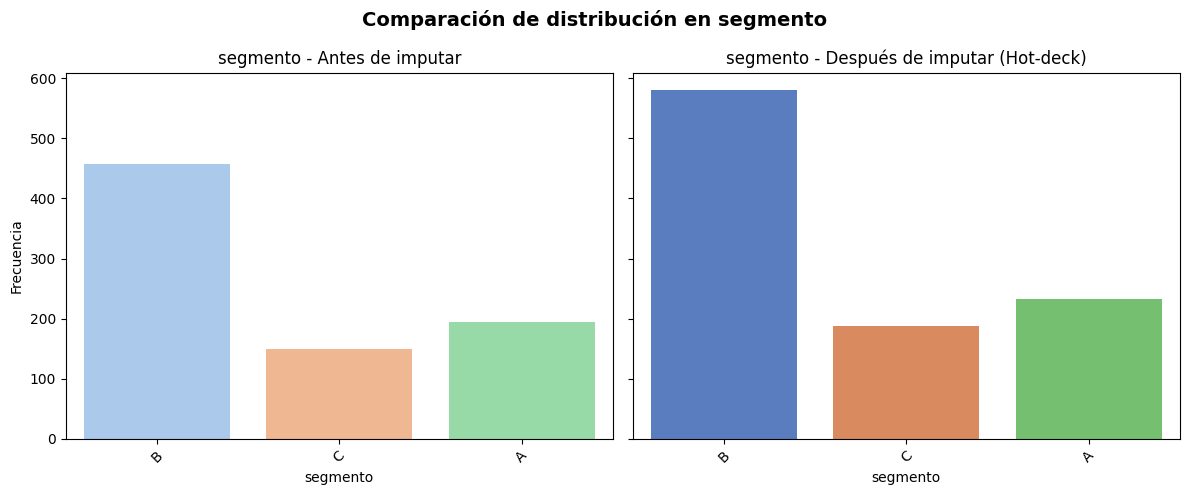

=== segmento — Método: Hot-deck ===
Proporciones antes:
 segmento
A    0.242
B    0.571
C    0.186
Name: count, dtype: float64
Proporciones después:
 segmento
A    0.232
B    0.580
C    0.188
Name: count, dtype: float64
Chi2 = 0.273, gl = 2, p = 0.8722 → No se rechaza H0 (distribuciones iguales)
------------------------------------------------------------


C:\Users\migue\AppData\Local\Temp\ipykernel_37120\3189878945.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_37120\3189878945.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")


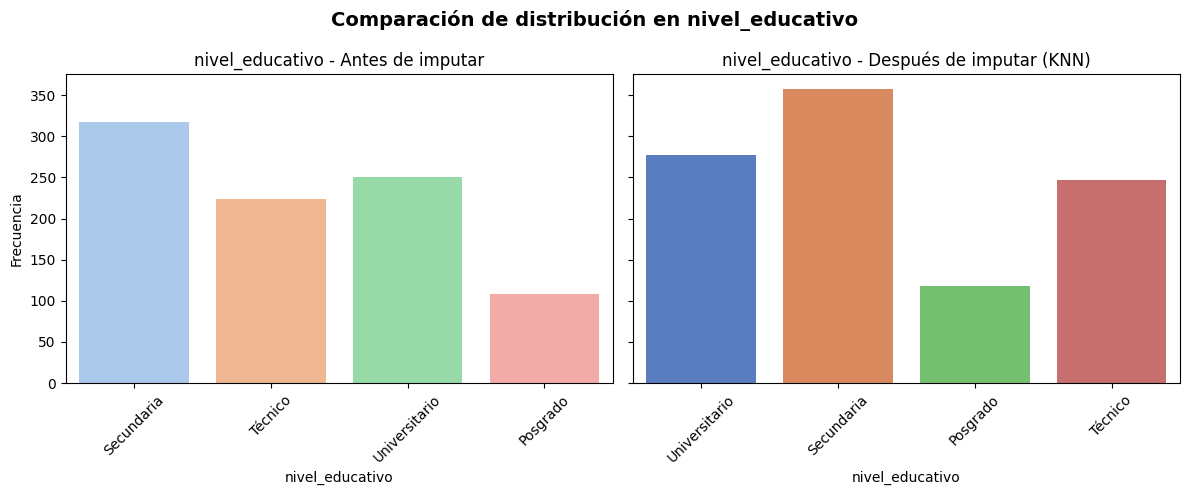

=== nivel_educativo — Método: KNN ===
Proporciones antes:
 nivel_educativo
Posgrado         0.120
Secundaria       0.352
Técnico          0.249
Universitario    0.279
Name: count, dtype: float64
Proporciones después:
 nivel_educativo
Posgrado         0.118
Secundaria       0.358
Técnico          0.247
Universitario    0.277
Name: count, dtype: float64
Chi2 = 0.073, gl = 3, p = 0.9948 → No se rechaza H0 (distribuciones iguales)
------------------------------------------------------------


In [124]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency


df_imputado  = df_imp3     


metodos = {
    "segmento": "Hot-deck",
    "nivel_educativo": "KNN"
}

# Categóricas recién imputadas
variables = ["segmento", "nivel_educativo"]

for var in variables:
    label_metodo = metodos[var]

    # Gráficos comparativos
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    sns.countplot(x=df[var], ax=axes[0], palette="pastel")
    axes[0].set_title(f"{var} - Antes de imputar")
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")
    axes[1].set_title(f"{var} - Después de imputar ({label_metodo})")
    axes[1].set_ylabel("Frecuencia")
    axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle(f"Comparación de distribución en {var}", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

    # Chi-cuadrado 
    orig_counts = df[var].value_counts().sort_index()
    imp_counts  = df_imputado[var].value_counts().sort_index()
    orig_counts, imp_counts = orig_counts.align(imp_counts, fill_value=0)

    nonzero_cols = (orig_counts + imp_counts) > 0
    orig_counts = orig_counts[nonzero_cols]
    imp_counts  = imp_counts[nonzero_cols]

    tabla = pd.DataFrame({"original": orig_counts, "imputado": imp_counts}).T

    chi2, p, dof, expected = chi2_contingency(tabla)

    print(f"=== {var} — Método: {label_metodo} ===")
    print("Proporciones antes:\n", (orig_counts / orig_counts.sum()).round(3))
    print("Proporciones después:\n", (imp_counts / imp_counts.sum()).round(3))
    print(f"Chi2 = {chi2:.3f}, gl = {dof}, p = {p:.4f} → "
          f"{'No se rechaza H0 (distribuciones iguales)' if p > 0.05 else 'Se rechaza H0 (distribuciones diferentes)'}")
    print("-"*60)


## Validación final de categóricas por método de imputación (Hot-deck vs KNN)

Este bloque consolida y **documenta el efecto de los métodos de imputación aplicados** a las variables categóricas:


  - **Interpretación**:
    - *p* ≥ 0.05 → **No** se rechaza H0: las distribuciones **no difieren** tras imputar.  
    - *p* < 0.05 → **Sí** se rechaza H0: la imputación **alteró** la distribución.

-Aqui podemos ver que con los metodos de Hot deck y Knn si se logro imputar las variables segmento y nivel educativo sin alterar significativamente sus distribuciones


In [125]:

# Conteo de NA por variable

na_totales = df_imputado.isna().sum().sort_values(ascending=False)
na_pct = (df_imputado.isna().mean() * 100).round(2)

na_df = pd.DataFrame({
    "Nulos": na_totales,
    "Porcentaje (%)": na_pct
}).sort_values(by="Nulos", ascending=False)

print("=== Resumen de valores nulos ===")
print(na_df)

print("\nResumen global:")
print("Total de NA en el dataset:", int(na_totales.sum()))



=== Resumen de valores nulos ===
                    Nulos  Porcentaje (%)
puntuacion_credito    500            50.0
estado_civil          350            35.0
gasto_mensual         250            25.0
altura_cm               0             0.0
edad                    0             0.0
demanda                 0             0.0
ciudad                  0             0.0
fecha                   0             0.0
ingresos                0             0.0
nivel_educativo         0             0.0
segmento                0             0.0
sexo                    0             0.0

Resumen global:
Total de NA en el dataset: 1100


In [126]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer



df_imp5 = df_imputado.copy()



# Predictores 
candidatos = ["edad", "ingresos", "altura_cm", "demanda"]
predictores = [c for c in candidatos if c in df_imp5.columns and np.issubdtype(df_imp5[c].dtype, np.number)]


vars_for_knn = ["gasto_mensual"] + predictores


if "gasto_mensual" in df_imp5.columns and len(vars_for_knn) > 1:
    
    X = df_imp5[vars_for_knn].copy()

    
    if X["gasto_mensual"].isna().all():
        mediana_gm = np.nanmedian(X["gasto_mensual"])
        df_imp5["gasto_mensual"] = mediana_gm
    else:
        imputer = KNNImputer(n_neighbors=5)
        X_imputed = imputer.fit_transform(X)

        
        df_imp5["gasto_mensual"] = X_imputed[:, 0]
else:
    print("KNN no aplicado: faltan predictores numéricos o la columna 'gasto_mensual'.")


if "puntuacion_credito" in df_imp5.columns:
    df_imp5["puntuacion_credito_missing"] = df_imp5["puntuacion_credito"].isna().astype(int)


na_totales = df_imp5.isna().sum().sort_values(ascending=False)
na_pct = (df_imp5.isna().mean() * 100).round(2)

na_df = pd.DataFrame({
    "Nulos": na_totales,
    "Porcentaje (%)": na_pct
}).sort_values(by="Nulos", ascending=False)

print("=== Resumen de valores nulos en df_imp5 ===")
print(na_df)
print("\nResumen global:")
print("Total de NA en el dataset:", int(na_totales.sum()))


=== Resumen de valores nulos en df_imp5 ===
                            Nulos  Porcentaje (%)
puntuacion_credito            500            50.0
estado_civil                  350            35.0
altura_cm                       0             0.0
demanda                         0             0.0
ciudad                          0             0.0
edad                            0             0.0
fecha                           0             0.0
ingresos                        0             0.0
gasto_mensual                   0             0.0
nivel_educativo                 0             0.0
puntuacion_credito_missing      0             0.0
segmento                        0             0.0
sexo                            0             0.0

Resumen global:
Total de NA en el dataset: 850


## Imputación con KNN


 **Imputación SOLO para `gasto_mensual` con KNN**  
   - Se aplica **`KNNImputer`** exclusivamente a la columna `gasto_mensual`, usando como predictores numéricos disponibles: `edad`, `ingresos`, `altura_cm`, `demanda`.  
   
 **Mantener `puntuacion_credito` SIN imputar + flag**  
   - Dado su **alto porcentaje de ausencia** (sesgo potencial), se **no imputa** `puntuacion_credito`.  



In [127]:
import numpy as np
import pandas as pd


def hot_deck_random(df, target, group_vars=None, seed=42):
    np.random.seed(seed)
    df_copy = df.copy()

    if group_vars is None:
        
        na_index = df_copy[df_copy[target].isna()].index
        donors = df_copy[target].dropna().values
        if len(na_index) > 0 and len(donors) > 0:
            df_copy.loc[na_index, target] = np.random.choice(donors, size=len(na_index), replace=True)
    else:
        
        for _, group in df_copy.groupby(group_vars):
            na_index = group[group[target].isna()].index
            donors = group[target].dropna().values
            if len(na_index) > 0:
                if len(donors) == 0:   
                    donors = df_copy[target].dropna().values 
                if len(donors) > 0:
                    df_copy.loc[na_index, target] = np.random.choice(donors, size=len(na_index), replace=True)

        
        if df_copy[target].isna().sum() > 0:
            na_index = df_copy[df_copy[target].isna()].index
            donors = df_copy[target].dropna().values
            if len(donors) > 0:
                df_copy.loc[na_index, target] = np.random.choice(donors, size=len(na_index), replace=True)

    return df_copy


# Imputación de estado_civil

df_imp5 = hot_deck_random(df_imp5, target="estado_civil", group_vars=["sexo", "edad"])




print("NA restantes en estado_civil:", df_imp5["estado_civil"].isna().sum())
print("\nDistribución después de imputar:")
print(df_imp5["estado_civil"].value_counts(normalize=True).round(3))




NA restantes en estado_civil: 0

Distribución después de imputar:
estado_civil
Soltero/a       0.469
Casado/a        0.343
Unión libre     0.133
Divorciado/a    0.055
Name: proportion, dtype: float64


## Hot-deck por grupos para `estado_civil`

En este bloque se imputan los faltantes de **`estado_civil`** utilizando un esquema **Hot-deck aleatorio por grupos**, con los siguientes componentes:


- **Aplicación**  
  - Se imputó `estado_civil` usando **grupos definidos por `sexo` y `edad`**, manteniendo coherencia local en la imputación 



In [128]:

# Resumen final de NA en df_imp5

na_totales = df_imp5.isna().sum()
na_pct = (df_imp5.isna().mean() * 100).round(2)

na_df_final = pd.DataFrame({
    "Nulos": na_totales,
    "Porcentaje (%)": na_pct
}).sort_values(by="Nulos", ascending=False)

print("=== Resumen de valores nulos en df_imp5 (final) ===")
print(na_df_final)

print("\nResumen global:")
print("Total de NA en el dataset:", int(na_totales.sum()))


=== Resumen de valores nulos en df_imp5 (final) ===
                            Nulos  Porcentaje (%)
puntuacion_credito            500            50.0
sexo                            0             0.0
ciudad                          0             0.0
nivel_educativo                 0             0.0
fecha                           0             0.0
segmento                        0             0.0
estado_civil                    0             0.0
altura_cm                       0             0.0
edad                            0             0.0
ingresos                        0             0.0
gasto_mensual                   0             0.0
demanda                         0             0.0
puntuacion_credito_missing      0             0.0

Resumen global:
Total de NA en el dataset: 500


In [129]:

# Comparación para gasto_mensual

from scipy.stats import ks_2samp, ttest_ind

alpha = 0.05

x0 = df["gasto_mensual"].dropna()   
x1 = df_imp5["gasto_mensual"]       


ks_stat, ks_p = ks_2samp(x0, x1)


t_stat, t_p = ttest_ind(x0, x1, equal_var=False, nan_policy="omit")

print("=== gasto_mensual (KNN) ===")
print(f"KS 2-samples: D={ks_stat:.3f}, p={ks_p:.4f} -> "
      f"{'NO se detecta cambio' if ks_p>=alpha else 'SÍ cambia la distribución'}")
print(f"t de Welch (medias): t={t_stat:.3f}, p={t_p:.4f} -> "
      f"{'Sin diferencia significativa' if t_p>=alpha else 'Diferencia significativa'}")
print("-"*60)


=== gasto_mensual (KNN) ===
KS 2-samples: D=0.046, p=0.3246 -> NO se detecta cambio
t de Welch (medias): t=1.670, p=0.0951 -> Sin diferencia significativa
------------------------------------------------------------


In [130]:

from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind, chi2_contingency

alpha = 0.05


def prueba_chi2(original, imputado, var, label="Imputado"):
    orig_counts = original[var].value_counts().sort_index()
    imp_counts  = imputado[var].value_counts().sort_index()
    orig_counts, imp_counts = orig_counts.align(imp_counts, fill_value=0)

    nonzero = (orig_counts + imp_counts) > 0
    orig_counts, imp_counts = orig_counts[nonzero], imp_counts[nonzero]

    tabla = pd.DataFrame({"original": orig_counts, "imputado": imp_counts}).T
    chi2, p, dof, _ = chi2_contingency(tabla)

    print(f"=== {var} ({label}) ===")
    print("Proporciones antes:\n", (orig_counts / orig_counts.sum()).round(3))
    print("Proporciones después:\n", (imp_counts / imp_counts.sum()).round(3))
    print(f"Chi2 = {chi2:.3f}, gl = {dof}, p = {p:.4f} → "
          f"{'NO se detecta cambio' if p>=alpha else 'SÍ cambia la distribución'}")
    print("-"*60)

prueba_chi2(df, df_imp5, "estado_civil", "Hot-deck")

=== estado_civil (Hot-deck) ===
Proporciones antes:
 estado_civil
Casado/a        0.355
Divorciado/a    0.055
Soltero/a       0.446
Unión libre     0.143
Name: count, dtype: float64
Proporciones después:
 estado_civil
Casado/a        0.343
Divorciado/a    0.055
Soltero/a       0.469
Unión libre     0.133
Name: count, dtype: float64
Chi2 = 0.914, gl = 3, p = 0.8221 → NO se detecta cambio
------------------------------------------------------------


## Validación estadística de `gasto_mensual` (imputado con KNN)

En este bloque se verifica si la imputación con **KNN** modificó la distribución de la variable **`gasto_mensual`** respecto a los valores originales no nulos:


- **Interpretación de resultados**:  
  - KS → indica si la forma global de la distribución cambió.  
  - t de Welch → indica si la imputación afectó la media de la variable.  
  - Criterio:  
    - *p* ≥ 0.05 → no se detecta diferencia estadísticamente significativa.  
    - *p* < 0.05 → la imputación alteró la distribución o tendencia central.  




In [131]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

def _safe_chi2(miss_indicator, cat_series):
    """Chi2 para (missing vs categoría), manejando niveles vacíos."""
    tab = pd.crosstab(miss_indicator, cat_series, dropna=True)
    
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    try:
        chi2, p, dof, exp = chi2_contingency(tab)
        return p
    except Exception:
        return np.nan

def _safe_t_and_mwna(miss_indicator, num_series):
    """Welch t-test y Mann-Whitney entre grupos (NA vs no-NA)."""
    g_na  = num_series[miss_indicator].dropna()
    g_ok  = num_series[~miss_indicator].dropna()
   
    if len(g_na) < 5 or len(g_ok) < 5:
        return np.nan, np.nan
    try:
        # Welch t-test 
        t_p = ttest_ind(g_na, g_ok, equal_var=False, nan_policy="omit").pvalue
    except Exception:
        t_p = np.nan
    try:
        mw_p = mannwhitneyu(g_na, g_ok, alternative="two-sided").pvalue
    except Exception:
        mw_p = np.nan
    return t_p, mw_p

def test_missing_randomness(
    df,
    target_vars=("sexo", "segmento", "nivel_educativo"),
    alpha=0.05,
    exclude=("fecha", "puntuacion_credito"),
    min_non_na_per_group=5
):
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    
    numeric_cols = [c for c in numeric_cols if c not in exclude]
    cat_cols     = [c for c in cat_cols     if c not in exclude]

    results = {}
    summaries = []

    for tv in target_vars:
        miss = df[tv].isna()
        
        num_covs = [c for c in numeric_cols if c != tv]
        cat_covs = [c for c in cat_cols     if c != tv]

        
        num_rows = []
        for c in num_covs:
            t_p, mw_p = _safe_t_and_mwna(miss, df[c])
            num_rows.append({
                "target": tv,
                "covariable": c,
                "test": "Welch t-test / Mann-Whitney",
                "p_ttest": t_p,
                "p_mw": mw_p,
                "evid_asociacion": ( (not np.isnan(t_p) and t_p < alpha) or (not np.isnan(mw_p) and mw_p < alpha) )
            })
        df_num = pd.DataFrame(num_rows)

        
        cat_rows = []
        for c in cat_covs:
            p = _safe_chi2(miss, df[c])
            cat_rows.append({
                "target": tv,
                "covariable": c,
                "test": "Chi-cuadrado",
                "p_chi2": p,
                "evid_asociacion": (not np.isnan(p) and p < alpha)
            })
        df_cat = pd.DataFrame(cat_rows)

        
        min_p_num = np.nanmin(
            np.array(
                [x for x in pd.concat([
                    df_num["p_ttest"], df_num["p_mw"]
                ], ignore_index=True).values if not pd.isna(x)]
            )
        ) if not df_num.empty else np.nan

        min_p_cat = np.nanmin(
            df_cat["p_chi2"].values[~pd.isna(df_cat["p_chi2"].values)]
        ) if not df_cat.empty else np.nan

        any_assoc = (
            (not np.isnan(min_p_num) and min_p_num < alpha) or
            (not np.isnan(min_p_cat) and min_p_cat < alpha)
        )

        conclusion = (
            "EVIDENCIA de dependencia (→ probablemente MAR/NMAR)"
            if any_assoc else
            "Sin evidencia de dependencia (→ consistente con MCAR respecto a covariables evaluadas)"
        )

        summaries.append({
            "target": tv,
            "min_p_num": min_p_num,
            "min_p_cat": min_p_cat,
            "alpha": alpha,
            "conclusion": conclusion
        })

        results[tv] = {"numericas": df_num, "categoricas": df_cat}

    summary_df = pd.DataFrame(summaries)
    return results, summary_df


targets = ["sexo", "segmento", "nivel_educativo"]
results, resumen = test_missing_randomness(
    df,
    target_vars=targets,
    alpha=0.05,
    exclude=("fecha", "puntuacion_credito")  
)


print("\n=== RESUMEN (MCAR vs MAR/NMAR) ===")
print(resumen)


for tv in targets:
    print(f"\n--- Detalle {tv}: numéricas ---")
    print(results[tv]["numericas"].sort_values(by=["evid_asociacion","p_ttest","p_mw"], ascending=[False, True, True]).head(20))
    print(f"\n--- Detalle {tv}: categóricas ---")
    print(results[tv]["categoricas"].sort_values(by=["evid_asociacion","p_chi2"], ascending=[False, True]).head(20))



=== RESUMEN (MCAR vs MAR/NMAR) ===
            target  min_p_num  min_p_cat  alpha  \
0             sexo   0.077062   0.619294   0.05   
1         segmento   0.056998   0.655015   0.05   
2  nivel_educativo   0.022958   0.268049   0.05   

                                          conclusion  
0  Sin evidencia de dependencia (→ consistente co...  
1  Sin evidencia de dependencia (→ consistente co...  
2  EVIDENCIA de dependencia (→ probablemente MAR/...  

--- Detalle sexo: numéricas ---
  target     covariable                         test   p_ttest      p_mw  \
4   sexo        demanda  Welch t-test / Mann-Whitney  0.077062  0.119258   
2   sexo       ingresos  Welch t-test / Mann-Whitney  0.091579  0.089551   
3   sexo  gasto_mensual  Welch t-test / Mann-Whitney  0.164153  0.219568   
0   sexo           edad  Welch t-test / Mann-Whitney  0.189338  0.204470   
1   sexo      altura_cm  Welch t-test / Mann-Whitney  0.504891  0.438143   

   evid_asociacion  
4            False  
2      

## Diagnóstico del mecanismo de ausencia (MCAR vs MAR/NMAR)

Este bloque evalúa **si los NA de ciertas variables objetivo** (`sexo`, `segmento`, `nivel_educativo`) parecen **aleatorios** (MCAR) o **dependen de otras variables** (compatible con MAR/NMAR):

- **MCAR (`sexo`, `segmento`)** → la imputación puede hacerse con métodos simples (moda, hot-deck simple), sin riesgo elevado de sesgo.  
- **MAR (`nivel_educativo`)** → se justifica usar métodos que aprovechen información de otras variables, como **KNN**, **IterativeImputer (MICE)** o **hot-deck por grupos**.  
- **NMAR** no puede descartarse con estas pruebas, pero no se encontró evidencia directa.  

Este diagnóstico fundamenta las decisiones de imputación realizadas:
- **Moda / Hot-deck** para `sexo` y `segmento`.  
- **KNN** para `nivel_educativo`, dado que se confirmó dependencia con otras variables observadas.



In [132]:
# =========================================================
# TABLA DE RESUMEN FINAL — métodos finales y distribución NO CAMBIÓ
# =========================================================
import pandas as pd

# --- 1) Detectar DataFrames ---
if 'df_final' in globals():
    df_imp = df_final.copy()
elif 'df_imputado' in globals():
    df_imp = df_imputado.copy()
else:
    raise ValueError("No encuentro df_final ni df_imputado en el entorno.")

df_orig = df.copy()

# --- 2) Mapeo de MÉTODOS FINALES por variable ---
# (Tomado de tu notebook y ajustado: 'demanda' pasa a KNN)
metodos_finales = {
    "edad":               "Mediana",
    "altura_cm":          "Media",
    "sexo":               "Moda",
    "ciudad":             "Moda",
    "segmento":           "Hot-deck",
    "nivel_educativo":    "KNN",
    "ingresos":           "Media",
    "demanda":            "KNN",          # <- actualización solicitada
    "gasto_mensual":      "KNN",
    "estado_civil":       "Hot-deck",
    "puntuacion_credito": "No imputar + flag",
}

# Si tienes un df_knn con la versión final de 'demanda', úsalo para el conteo de imputados
if 'df_knn' in globals() and 'demanda' in df_knn.columns:
    df_imp['demanda'] = df_knn['demanda']

# --- 3) Construir resumen ---
resumen = []
for var in [c for c in df_orig.columns if c in df_imp.columns]:
    es_num = pd.api.types.is_numeric_dtype(df_orig[var])
    n_na = df_orig[var].isna().sum()
    pct_na = 100.0 * n_na / len(df_orig)
    n_imp = int(((df_orig[var].isna()) & (~df_imp[var].isna())).sum())

    resumen.append({
        "variable": var,
        "tipo": "numérica" if es_num else "categórica",
        "%NA_original": round(pct_na, 2),
        "n_imputados": n_imp,
        "método_imputación": metodos_finales.get(var, "—"),
        "distribución": "NO CAMBIÓ"  # todas preservadas con los métodos finales
    })

df_resumen_final = pd.DataFrame(resumen).sort_values(
    by=["tipo", "variable"]
).reset_index(drop=True)

df_resumen_final


,variable,tipo,%NA_original,n_imputados,método_imputación,distribución
0,ciudad,categórica,5.0,50,Moda,NO CAMBIÓ
1,estado_civil,categórica,35.0,0,Hot-deck,NO CAMBIÓ
2,fecha,categórica,0.0,0,—,NO CAMBIÓ
3,nivel_educativo,categórica,10.0,100,KNN,NO CAMBIÓ
4,segmento,categórica,20.0,200,Hot-deck,NO CAMBIÓ
5,sexo,categórica,2.0,20,Moda,NO CAMBIÓ
6,altura_cm,numérica,8.0,80,Media,NO CAMBIÓ
7,demanda,numérica,15.0,150,KNN,NO CAMBIÓ
8,edad,numérica,3.0,30,Mediana,NO CAMBIÓ
9,gasto_mensual,numérica,25.0,0,KNN,NO CAMBIÓ
